# **CREDIT CARD DEAULT PREDICTION PROJECT**

 **Research Question**

 To what extent can Machine Learning Models utilise customer Financial Behaviour to predict credit card default ?



# **Importing Libraries**

In [ ]:
#import libraries
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier


# **Load Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load dataset
df = pd.read_excel("/content/drive/MyDrive/Herts/default of credit card clients.xls", header=1)

In [ ]:
# Rename target column for simplicity
df.rename(columns={'default payment next month': 'default'}, inplace=True)

In [ ]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default'],
      dtype='object')

In [ ]:
df.shape

(30000, 25)

In [ ]:
# Preview dataset
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


# **Data Cleaning**

In [ ]:
# Check structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3   30000 non-null  int64
 21  PAY_AMT4   3

In [ ]:
# Check summary statistics
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [ ]:
# Check if there is any duplicate IDs
condition = df.duplicated(subset = 'ID').any()

if condition:
    print('There are duplicate IDs')
else:
    print('No duplicate IDs')

No duplicate IDs


In [ ]:
print(df['SEX'].unique())
print(df['SEX'].value_counts())

[2 1]
SEX
2    18112
1    11888
Name: count, dtype: int64


In [ ]:
print(df['EDUCATION'].unique())
print(df['EDUCATION'].value_counts())

[2 1 3 5 4 6 0]
EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64


In [ ]:
df["EDUCATION"] = df["EDUCATION"].replace({4:0,5:0,6:0})
df["EDUCATION"].value_counts()

,count
EDUCATION,
2,14030
1,10585
3,4917
0,468


In [ ]:
print(df['MARRIAGE'].unique())
print(df['MARRIAGE'].value_counts())


[1 2 3 0]
MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64


In [ ]:
# cheching missimg values
df.isnull().sum()

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


# **Exploratry Data Analysis**

# Default Distribution

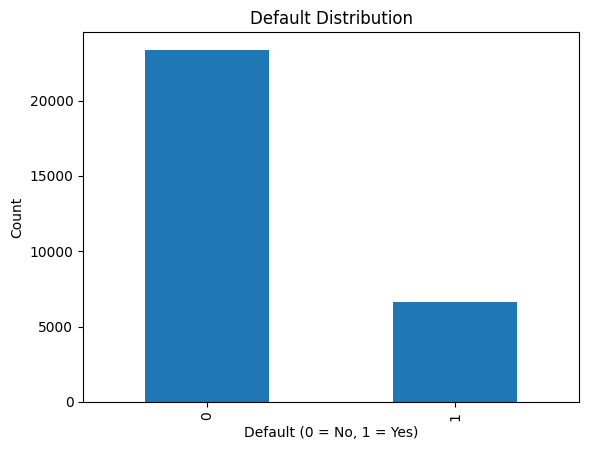

default
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [ ]:
# Default distribution
df['default'].value_counts().plot(kind='bar')
plt.title("Default Distribution")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# Percentage
print(df['default'].value_counts(normalize=True))

# Credit Limit Distribution

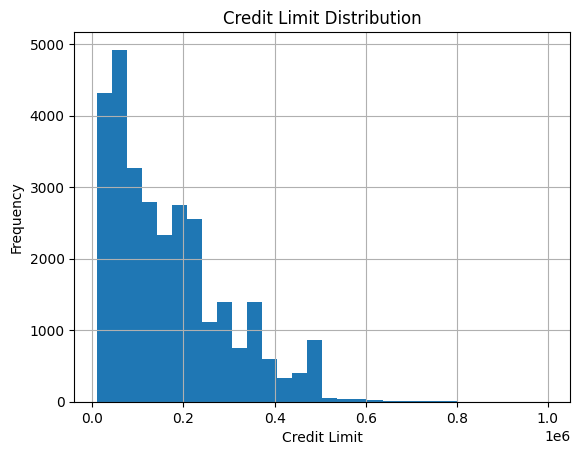

In [ ]:
# Credit limit distribution
df['LIMIT_BAL'].hist(bins=30)
plt.title("Credit Limit Distribution")
plt.xlabel("Credit Limit")
plt.ylabel("Frequency")
plt.show()

# Gender Distribution

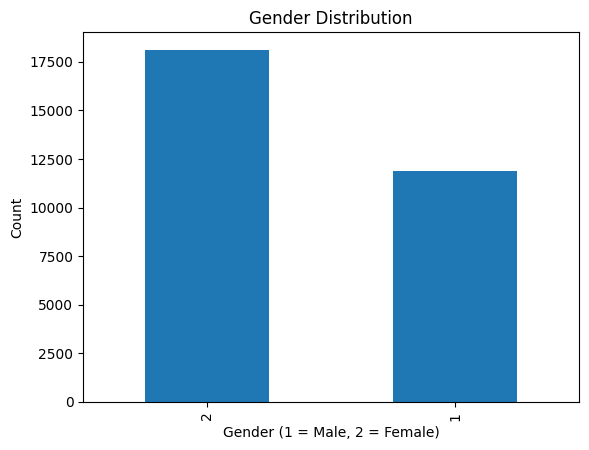

SEX
2    0.603733
1    0.396267
Name: proportion, dtype: float64


In [ ]:
# Gender distribution
df['SEX'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.xlabel("Gender (1 = Male, 2 = Female)")
plt.ylabel("Count")
plt.show()

print(df['SEX'].value_counts(normalize=True))

# Education Level Distribution

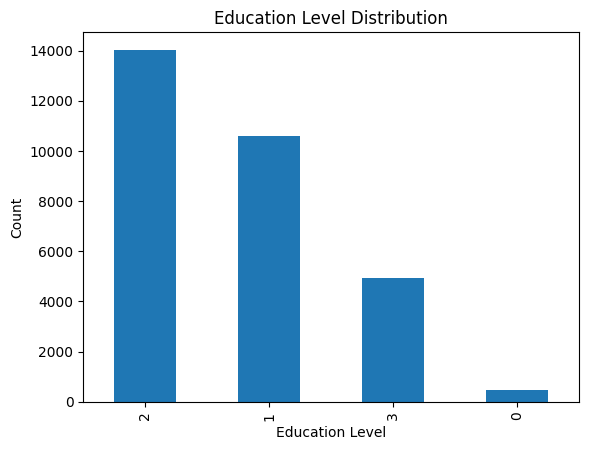

In [ ]:
# Education level distribution
df['EDUCATION'].value_counts().plot(kind='bar')
plt.title("Education Level Distribution")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.show()

# Default vs Gender

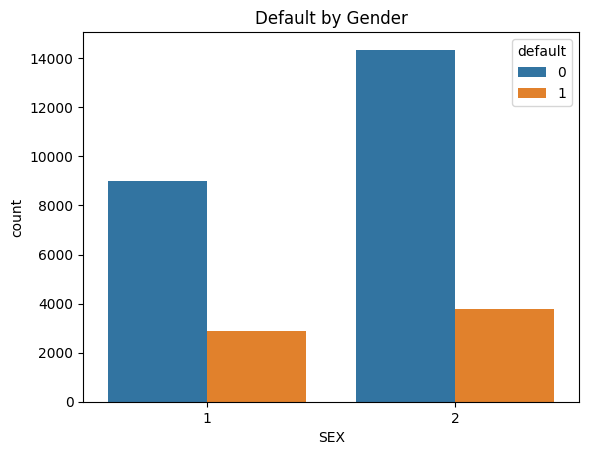

In [ ]:
import seaborn as sns

sns.countplot(x='SEX', hue='default', data=df)
plt.title("Default by Gender")
plt.show()

# Default vs Education

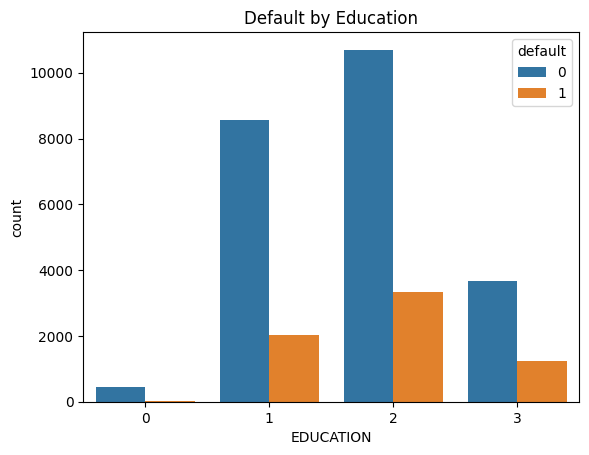

In [ ]:
sns.countplot(x='EDUCATION', hue='default', data=df)
plt.title("Default by Education")
plt.show()

# Repayment Delays

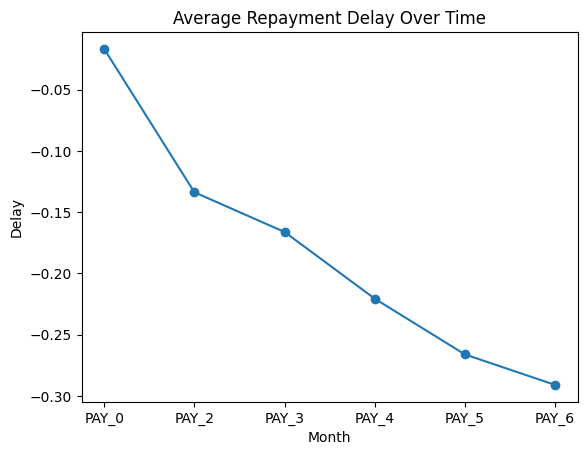

In [ ]:
# Average delay across months
delay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

df[delay_cols].mean().plot(marker='o')
plt.title("Average Repayment Delay Over Time")
plt.xlabel("Month")
plt.ylabel("Delay")
plt.show()

# Bill Amount Growth

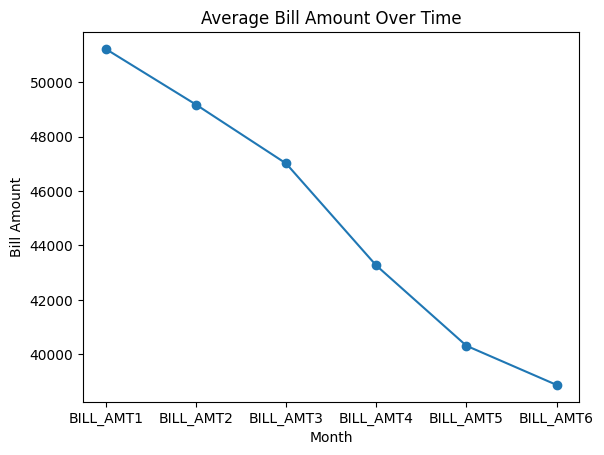

In [ ]:
bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']

df[bill_cols].mean().plot(marker='o')
plt.title("Average Bill Amount Over Time")
plt.xlabel("Month")
plt.ylabel("Bill Amount")
plt.show()

# Payment Behaviour

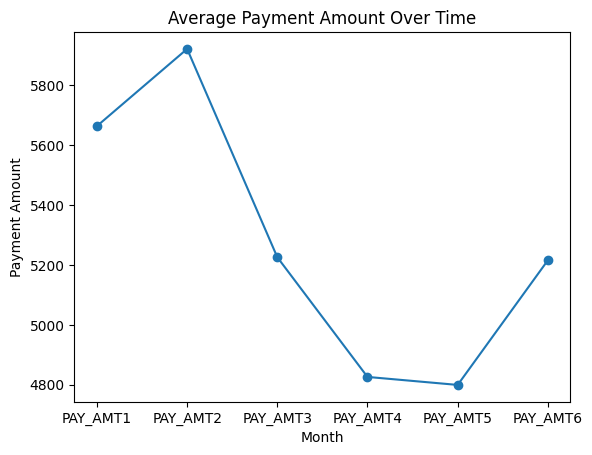

In [ ]:
pay_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']

df[pay_cols].mean().plot(marker='o')
plt.title("Average Payment Amount Over Time")
plt.xlabel("Month")
plt.ylabel("Payment Amount")
plt.show()

# Bills vs Payments

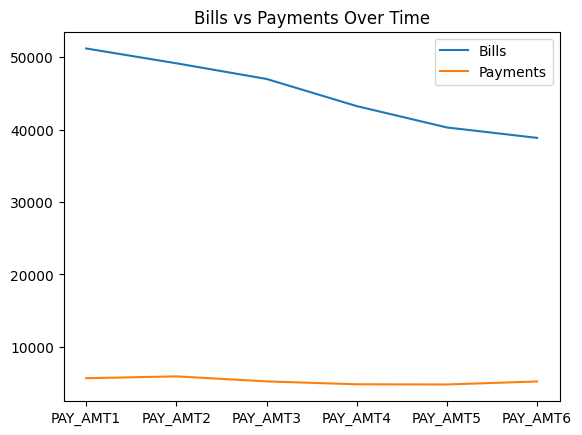

In [ ]:
# Compare bills vs payments
df[bill_cols].mean().plot(label='Bills')
df[pay_cols].mean().plot(label='Payments')

plt.title("Bills vs Payments Over Time")
plt.legend()
plt.show()

# Repayment Ratio

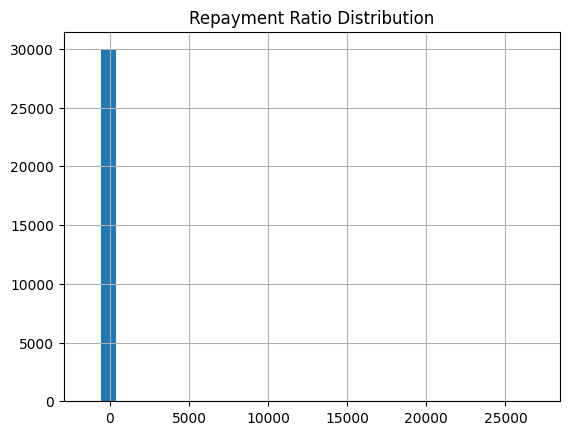

In [ ]:
# Repayment ratio
df['avg_bill'] = df[bill_cols].mean(axis=1)
df['avg_payment'] = df[pay_cols].mean(axis=1)

df['repayment_ratio'] = df['avg_payment'] / (df['avg_bill'] + 1)

df['repayment_ratio'].hist(bins=30)
plt.title("Repayment Ratio Distribution")
plt.show()

# Behaviour Instability

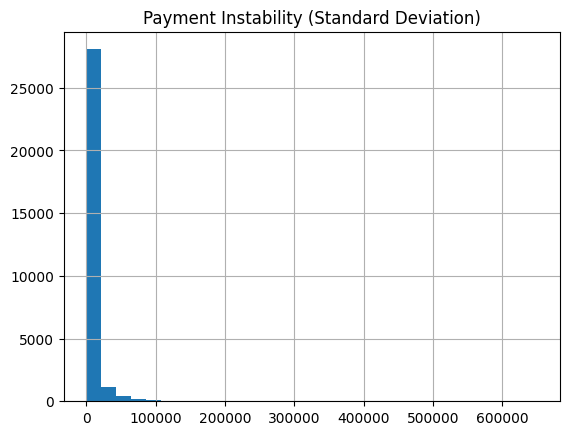

In [ ]:
# Payment instability
df['payment_std'] = df[pay_cols].std(axis=1)

df['payment_std'].hist(bins=30)
plt.title("Payment Instability (Standard Deviation)")
plt.show()

# Default vs Behaviour

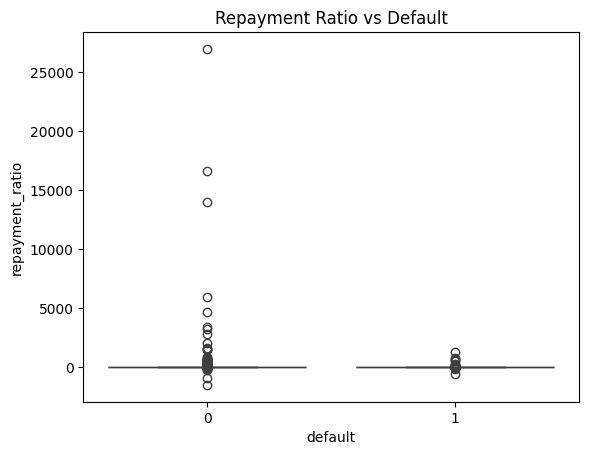

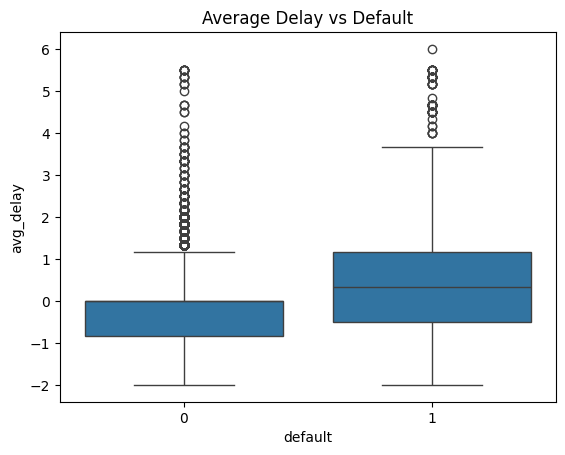

In [ ]:
# Repayment ratio vs default
sns.boxplot(x='default', y='repayment_ratio', data=df)
plt.title("Repayment Ratio vs Default")
plt.show()

# Delay vs default
df['avg_delay'] = df[delay_cols].mean(axis=1)

sns.boxplot(x='default', y='avg_delay', data=df)
plt.title("Average Delay vs Default")
plt.show()

# Correlation Heatmap

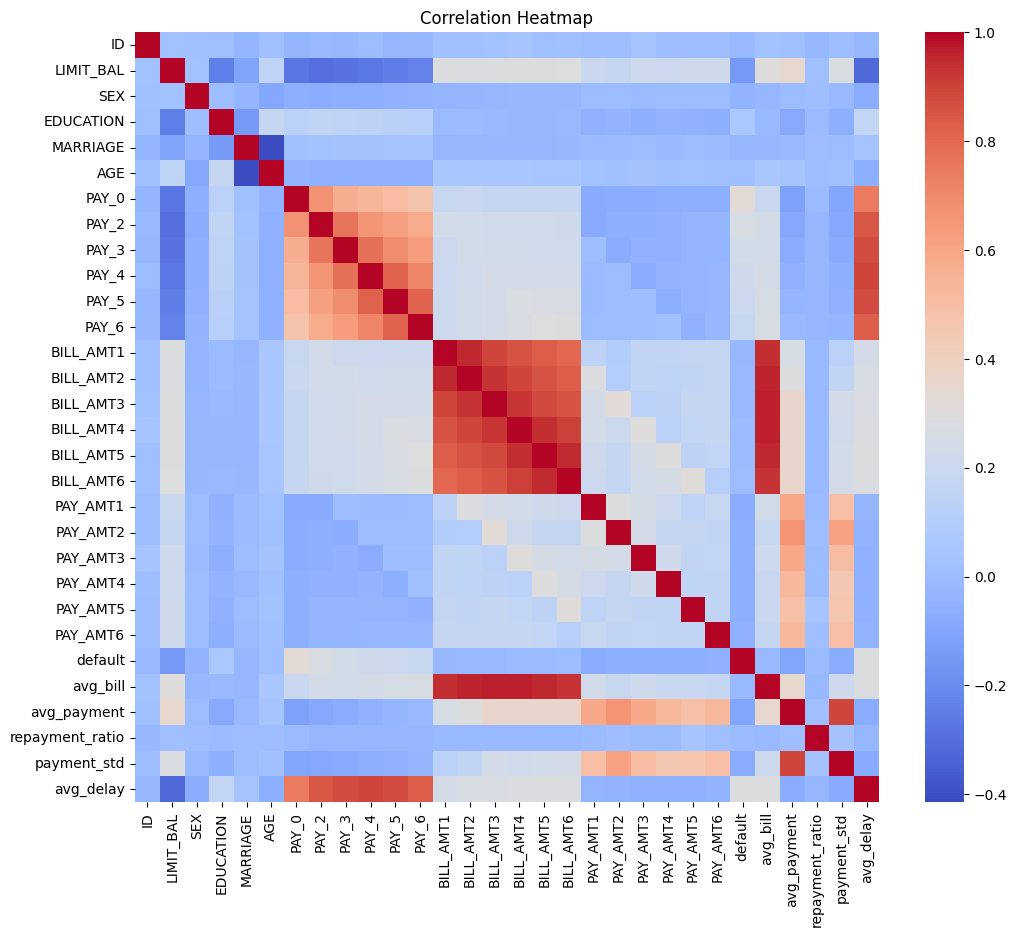

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# FEATURE ENGINEERING

In [ ]:
# Define column groups
bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']
delay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

# Average bill
df['avg_bill'] = df[bill_cols].mean(axis=1)

# Credit utilisation ratio
df['credit_utilisation'] = df['avg_bill'] / df['LIMIT_BAL']

# Average payment
df['avg_payment'] = df[pay_cols].mean(axis=1)

# Repayment ratio
df['repayment_ratio'] = df['avg_payment'] / (df['avg_bill'] + 1)

# Delay trend (recent vs past)
df['delay_trend'] = df['PAY_0'] - df['PAY_6']

# Average delay
df['avg_delay'] = df[delay_cols].mean(axis=1)

# Growth in bill amount
df['bill_growth'] = df['BILL_AMT1'] - df['BILL_AMT6']

# Payment instability
df['payment_std'] = df[pay_cols].std(axis=1)

# Bill instability
df['bill_std'] = df[bill_cols].std(axis=1)

df[['credit_utilisation','repayment_ratio','avg_delay','bill_growth','payment_std']].head()

,credit_utilisation,repayment_ratio,avg_delay,bill_growth,payment_std
0,0.064200,0.089364,-0.333333,3913,281.283072
1,0.023718,0.292689,0.500000,-579,752.772653
2,0.188246,0.108382,0.000000,13690,1569.815488
3,0.771113,0.036258,0.000000,17443,478.058155
4,0.364463,0.540025,-0.333333,-10514,13786.230736


# Data Preparation for Modelling

In [ ]:
# Data Preparation for Modelling

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features and target
X = df.drop(columns=['default', 'ID'])
y = df['default']

# Check for NaNs after feature engineering and fill them
# For standard deviation, NaN often implies insufficient data or no variability, so filling with 0 is appropriate.
if X.isnull().sum().any():
    print("NaNs found in X after feature engineering. Filling with 0.")
    X = X.fillna(0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scaling (only for models that need it)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preparation complete")

NaNs found in X after feature engineering. Filling with 0.
Data preparation complete


# MODEL BUILDING

# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Train model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_log = log_model.predict(X_test_scaled)

# Evaluation
print("Logistic Regression Results")
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:,1]))

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.35      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000

ROC-AUC: 0.7136949407610396


# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]))

Random Forest Results
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.63      0.37      0.47      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.66      0.68      6000
weighted avg       0.79      0.81      0.79      6000

ROC-AUC: 0.7635424590365116


# XGBoost

In [ ]:
from xgboost import XGBClassifier

# Train model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
print("XGBoost Results")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]))

XGBoost Results
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.63      0.37      0.47      1327

    accuracy                           0.81      6000
   macro avg       0.73      0.66      0.68      6000
weighted avg       0.79      0.81      0.79      6000

ROC-AUC: 0.7608814670885078


# HYPERPARAMETER TUNING

In [ ]:
# Hyperparameter Tuning (Random Forest)

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# Grid search
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

# Train
grid.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


**Evaluate Tuned Model**

In [ ]:
# Best model
best_rf = grid.best_estimator_

# Predictions
y_pred_best = best_rf.predict(X_test)

# Evaluation
print("=== Tuned Random Forest ===")
print(classification_report(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1]))

=== Tuned Random Forest ===
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.65      0.35      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000

ROC-AUC: 0.7807587592530387


# Evaluate Tuned Model

In [ ]:
# Evaluate tuned Random Forest
print("=== Tuned Random Forest ===")
print(classification_report(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1]))

=== Tuned Random Forest ===
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.65      0.35      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000

ROC-AUC: 0.7807587592530387


# Model Comparison Table

In [ ]:
# Model Comparison

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

# Logistic Regression
results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_log),
    'Precision': precision_score(y_test, y_pred_log),
    'Recall': recall_score(y_test, y_pred_log),
    'F1 Score': f1_score(y_test, y_pred_log),
    'ROC-AUC': roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:,1])
})

# Random Forest
results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1 Score': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])
})

# XGBoost
results.append({
    'Model': 'XGBoost',
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1 Score': f1_score(y_test, y_pred_xgb),
    'ROC-AUC': roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1])
})

# Tuned Random Forest
results.append({
    'Model': 'Tuned Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred_best),
    'Precision': precision_score(y_test, y_pred_best),
    'Recall': recall_score(y_test, y_pred_best),
    'F1 Score': f1_score(y_test, y_pred_best),
    'ROC-AUC': roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1])
})

results_df = pd.DataFrame(results)

# Show sorted results
results_df.sort_values(by='ROC-AUC', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Tuned Random Forest,0.814167,0.650568,0.345139,0.451009,0.780759
1,Random Forest,0.813333,0.632863,0.371515,0.468186,0.763542
2,XGBoost,0.812500,0.627848,0.373775,0.468588,0.760881
0,Logistic Regression,0.807333,0.688742,0.235117,0.350562,0.713695


# Model Comparison Plot

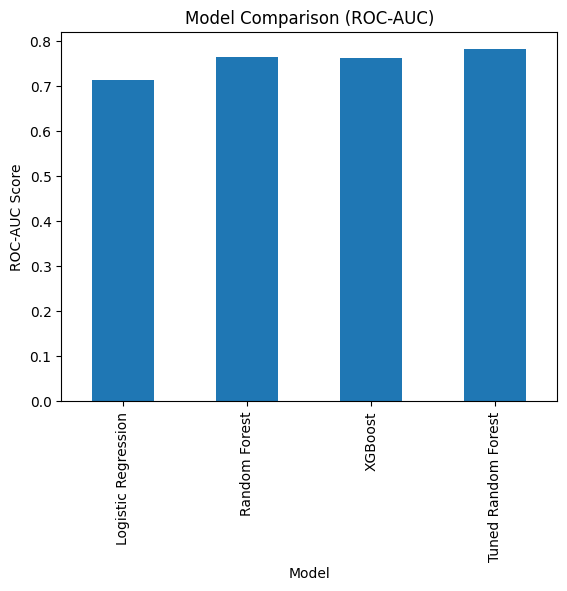

In [ ]:
# Visual comparison

results_df.set_index('Model')['ROC-AUC'].plot(kind='bar')
plt.title("Model Comparison (ROC-AUC)")
plt.ylabel("ROC-AUC Score")
plt.show()

# Feature Importance

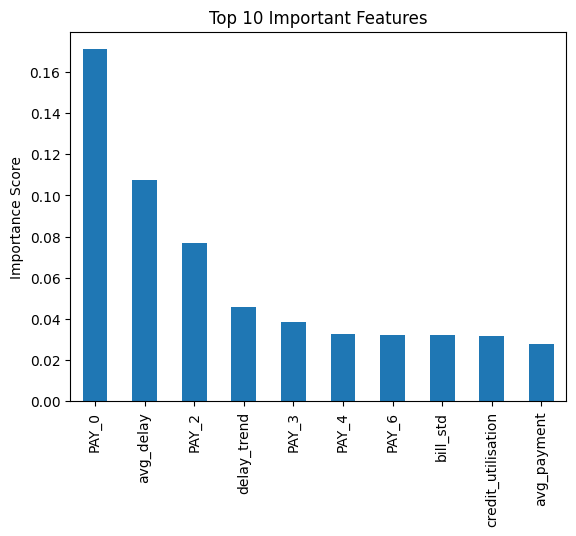

In [ ]:
# Feature importance
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top 10 Important Features")
plt.ylabel("Importance Score")
plt.show()

# Confusion Matrix

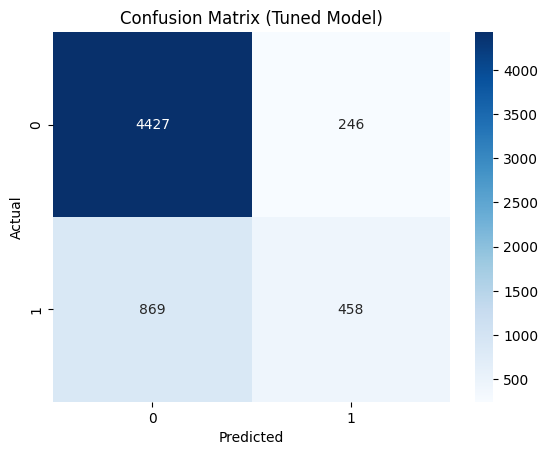

In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Tuned Ramdom Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()